## Notebook to learn to play with tif images

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
import random
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt

import experiment_settings
import build_model
import train_model
import build_data
import methods
import read_landsat

import tensorflow as tf


In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"tensorflow version = {tf.__version__}")

# tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on
print(tf.config.list_physical_devices("GPU"))

python version = 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:12:31) [Clang 14.0.6 ]
numpy version = 1.23.2
tensorflow version = 2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# GET SETTINGS
EXP_NAME = "exp0"
settings = experiment_settings.get_settings(EXP_NAME)
settings["mode"] = "training"
# display(settings)

# SET RANDOM SEEDS
np.random.seed(settings["rng_seed"])
random.seed(settings["rng_seed"])
tf.random.set_seed(settings["rng_seed"])


In [4]:
# LOAD THE DATA
imp.reload(build_data)
imp.reload(methods)
imp.reload(read_landsat)

tags_train, tags_val = build_data.get_tags(settings)

tfds_train = build_data.build_tf_dataset(settings, tags_train, settings["batch_size"])
tfds_val = build_data.build_tf_dataset(settings, tags_val, settings["batch_size"])

batch_shape = np.shape(next(tfds_val.as_numpy_iterator())[0])
print(f"{batch_shape = }")


-90.0 90.0 -180.0 180.0
/n
landsat_-7lat_105lon_2015
...frac_land.round(3) = 0.006, # samples = 160
landsat_-7lat_106lon_2015
...frac_land.round(3) = 0.283, # samples = 7040
landsat_-7lat_107lon_2015
...frac_land.round(3) = 0.614, # samples = 15232
landsat_-6lat_105lon_2015
...frac_land.round(3) = 0.424, # samples = 10528
landsat_-6lat_106lon_2015
...frac_land.round(3) = 0.97, # samples = 24064
landsat_-6lat_107lon_2015
...frac_land.round(3) = 0.912, # samples = 22656
landsat_-5lat_105lon_2015
...frac_land.round(3) = 0.742, # samples = 18432
landsat_-5lat_106lon_2015
...frac_land.round(3) = 0.129, # samples = 3232
landsat_-5lat_107lon_2015
...frac_land.round(3) = 0.029, # samples = 736
landsat_33lat_71lon_2015
...frac_land.round(3) = 1.0, # samples = 24800
landsat_33lat_72lon_2015
...frac_land.round(3) = 1.0, # samples = 24800
landsat_33lat_73lon_2015
...frac_land.round(3) = 1.0, # samples = 24800
landsat_34lat_71lon_2015
...frac_land.round(3) = 1.0, # samples = 24800
landsat_34lat_72l

KeyboardInterrupt: 

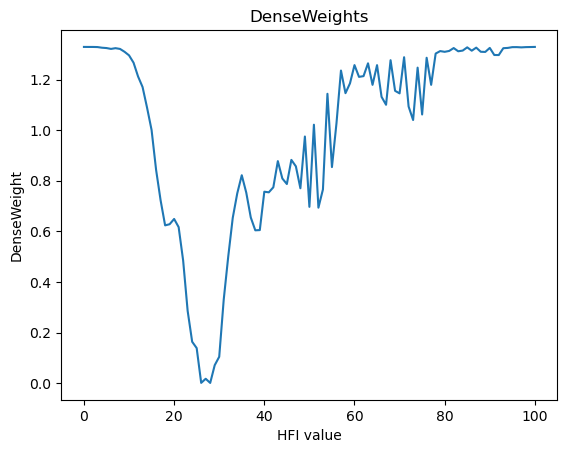

In [ ]:
imp.reload(methods)
denseweights = methods.get_denseweights(settings, tags_train)

plt.title("DenseWeights")
plt.plot(np.arange(0, 101, 1), denseweights)
plt.xlabel("HFI value")
plt.ylabel("DenseWeight")
plt.show()

In [ ]:
# TRAIN THE MODEL
imp.reload(build_model)
imp.reload(train_model)
imp.reload(methods)

tf.keras.backend.clear_session()
model = build_model.build_model(settings, input_shape=(batch_shape[1:]))

settings["mode"] = "training"
model, fit_summary, history, settings = train_model.train_model(
    settings, model, tfds_train, tfds_val, denseweights
)
fit_summary

Epoch 1/1000
 25/500 [>.............................] - ETA: 1:10 - loss: 19.9242 - mae: 19.2881

KeyboardInterrupt: 

In [ ]:
print("training complete.")
